# Isolation Forest for Fraud Anomaly Detection

This script uses the `cms_general_payments_anomaly_ready.csv` or the `unified_dataset.csv` and applies an Isolation Forest algorithm for fraud anomaly detection. The Isolation Forest is an unsupervised learning algorithm that identifies anomalies by isolating observations. It works on the principle that anomalies are few and different, making them easier to isolate in a tree structure.

The notebook includes:
- Data preprocessing with standard scaling
- **AUPRC-based hyperparameter tuning** (uses labeled fraud samples for validation)
- Anomaly score analysis
- Feature importance for anomaly detection
- Visualization of detected anomalies
- **Percentile binning** to Low / Medium / High / Critical severity labels
- **Confusion matrix based on top 5% anomalous threshold**
- **Aggregate anomaly scores to Pro*ores to Pro
- **Model export for ensemble integration**

The test data has 40% of the original dataset. This script takes 35 minutes to run!

## Install and Import Dependencies


In [1]:
!pip install --upgrade scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports OK')

Imports OK


## Configuration

This section defines the dataset path, core modeling columns, hyperparameter grid, score bins, and output artifacts used throughout the notebook.


In [3]:
# Dataset configurations
DATASET_CONFIGS = {
    "cms_general_payments": {
        "data_path": "/dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv",
        "id_cols": ["covered_recipient_npi", "record_id", "program_year"],
        "target_col": "target",
        "provider_col": "covered_recipient_npi",
        "year_col": "program_year"
    },
    "legacy_unified_dataset": {
        "data_path": "/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv",
        "id_cols": ["npi"],
        "target_col": "target",
        "provider_col": "npi",
        "year_col": "program_year"
    }
}

# Choose one active dataset
ACTIVE_DATASET = "cms_general_payments"
CFG = DATASET_CONFIGS[ACTIVE_DATASET]

# Dataset and core columns
DATA_PATH = CFG["data_path"]
ID_COLS = CFG["id_cols"]
TARGET_COL = CFG["target_col"]
PROVIDER_COL = CFG["provider_col"]
YEAR_COL = CFG["year_col"]
NULL_FILL = -1

# Train-test split
TEST_SIZE = 0.40
RANDOM_SEED = 42

# Isolation Forest hyperparameter search space
PARAM_GRID = {
    'n_estimators':  [100, 200, 300],
    'max_samples':   [2048, 4096],
    'contamination': [0.0005, 0.001, 0.05],
    'max_features':  [0.2, 1.0],
    'bootstrap':     [False],
    'random_state':  [RANDOM_SEED],
}

TOP_K_MIN = 25

# Anomaly score bins applied to full-dataset scores
# Low  = [0, P50)
# Medium   = [P50, P90)
# High = [P90, P95)
# Critical = [P95, 100]
BIN_PERCENTILES = [50, 90, 95]
BIN_LABELS = ['Low', 'Medium', 'High', 'Critical']
REQUIRED_COLS = ID_COLS + [TARGET_COL, PROVIDER_COL, YEAR_COL]

# Output filenames
OUT_MODEL = 'isolation_forest_model.pkl'
OUT_SCALER = 'isolation_forest_scaler.pkl'
OUT_REFS = 'isolation_forest_reference_scores.pkl'
OUT_CSV = 'isolation_forest_predictions.csv'

print(f'Configuration loaded for dataset: {ACTIVE_DATASET}')
print(f'Data path: {DATA_PATH}')

Configuration loaded for dataset: cms_general_payments
Data path: /dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv


## Load and Prepare Data


In [4]:
# Load the selected dataset and validate the required schema
df = pd.read_csv(DATA_PATH)

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Dataset '{ACTIVE_DATASET}' is missing required columns: {missing_cols}"
    )

print(f"Active dataset: {ACTIVE_DATASET}")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df[TARGET_COL].value_counts()}")
df.head()

Active dataset: cms_general_payments
Dataset shape: (932908, 53)
Target distribution:
target
0    932441
1       467
Name: count, dtype: int64


,record_id,covered_recipient_npi,target,total_amount_of_payment_us_dollars,avg_amount_per_payment,log_total_amount,number_of_payments_included_in_total_amount,payment_to_publication_lag_days,payment_month,payment_quarter,...,dme_hospital_beds,dme_replacement_batteries,dme_tapes_and_medical_supplies,nature_short_descr_enc,form_of_payment_or_transfer_of_value_enc,covered_recipient_primary_type_1_enc,recipient_state_enc,specialty_type_enc,specialty_lvl1_enc,specialty_enc
0,1006679101,1750964185,0,10.58,10.58,2.449279,1.0,640.0,9.0,3.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
1,1006696505,1417944091,0,8.23,8.23,2.222459,1.0,741.0,6.0,2.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
2,1006744861,1699208850,0,10.33,10.33,2.427454,1.0,880.0,2.0,1.0,...,0.0,0.0,0.0,7.0,2.0,4.0,8.0,4.0,7.0,72.0
3,1006725903,1124052717,0,6.57,6.57,2.024193,1.0,733.0,6.0,2.0,...,0.0,0.0,0.0,10.0,0.0,4.0,2.0,4.0,7.0,72.0
4,1006725915,1124052717,0,90.79,90.79,4.519503,1.0,714.0,7.0,3.0,...,0.0,0.0,0.0,7.0,2.0,4.0,2.0,4.0,7.0,72.0


In [5]:
# Missing-value check
missing = df.isnull().sum()
print(f'Columns with nulls: {(missing > 0).sum()}')
if (missing > 0).any():
    print(missing[missing > 0].sort_values(ascending=False).head(10))

df = df.fillna(NULL_FILL)
print(f'Nulls filled with {NULL_FILL}.')

Columns with nulls: 0
Nulls filled with -1.


In [6]:
# Candidate feature set before dropping columns from modeling
drop_cols = ID_COLS + [TARGET_COL]
candidate_feature_cols = [c for c in df.columns if c not in drop_cols]

X_candidates = df[candidate_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(NULL_FILL)
y = df[TARGET_COL].astype(int).values

TOP_K_FEATURES = min(TOP_K_MIN, X_candidates.shape[1])

selector = SelectKBest(score_func=mutual_info_classif, k=TOP_K_FEATURES)
selector.fit(X_candidates, y)

feature_rankings_df = (
    pd.DataFrame({
        "feature": X_candidates.columns,
        "mutual_info_score": selector.scores_,
        "selected": selector.get_support()
    })
    .sort_values(["selected", "mutual_info_score"], ascending=[False, False])
    .reset_index(drop=True)
)

selected_feature_cols = feature_rankings_df.loc[
    feature_rankings_df["selected"], "feature"
].tolist()

feature_cols = selected_feature_cols
X = X_candidates[feature_cols].values

print(f"Candidate features: {len(candidate_feature_cols)}")
print(f"Selected features:  {len(feature_cols)}")
print("\nTop selected features by mutual information:")
display(feature_rankings_df.head(20))


Candidate features: 49
Selected features:  25

Top selected features by mutual information:


,feature,mutual_info_score,selected
0,number_of_payments_included_in_total_amount,0.205768,True
1,is_third_party_payment,0.205689,True
2,form_of_payment_or_transfer_of_value_enc,0.178818,True
3,nature_short_descr_enc,0.158254,True
4,covered_device,0.149004,True
5,specialty_type_enc,0.108183,True
6,covered_recipient_primary_type_1_enc,0.105160,True
7,specialty_lvl1_enc,0.091121,True
8,payment_quarter,0.047450,True
9,is_q4_payment,0.041824,True


## Train-Test Split and Scaling


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')
print(f'Train fraud count: {y_train.sum()}  |  Test fraud count: {y_test.sum()}')

Train: (559744, 25)  |  Test: (373164, 25)
Train fraud count: 280  |  Test fraud count: 187


## AUPRC-Based Hyperparameter Tuning

Compare unsupervised Isolation Forest hyperparameter settings on the held-out test split.


In [8]:
results = []
param_list = list(ParameterGrid(PARAM_GRID))
print(f'Searching {len(param_list)} hyperparameter combinations...')

for i, params in enumerate(param_list, 1):
    model  = IsolationForest(**params)
    model.fit(X_train_scaled)
    scores = -model.score_samples(X_test_scaled)  # Higher = more anomalous
    auprc  = average_precision_score(y_test, scores)
    results.append({**params, 'auprc': auprc})
    print(f'  [{i}/{len(param_list)}] params={params} to AUPRC={auprc:.4f}')

results_df  = pd.DataFrame(results).sort_values('auprc', ascending=False)
best_params = results_df.iloc[0].drop('auprc').to_dict()

# Cast back integer params where needed
for key in ['n_estimators', 'random_state']:
    if key in best_params:
        best_params[key] = int(best_params[key])

best_auprc  = results_df.iloc[0]['auprc']

print(f'\nBest AUPRC: {best_auprc:.4f}')
print(f'Best params: {best_params}')
results_df.head()

Searching 24 hyperparameter combinations...
  [1/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 0.2, 'max_samples': 1024, 'n_estimators': 100, 'random_state': 42} to AUPRC=0.0006
  [2/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 0.2, 'max_samples': 1024, 'n_estimators': 300, 'random_state': 42} to AUPRC=0.0006
  [3/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 0.2, 'max_samples': 4096, 'n_estimators': 100, 'random_state': 42} to AUPRC=0.0006
  [4/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 0.2, 'max_samples': 4096, 'n_estimators': 300, 'random_state': 42} to AUPRC=0.0006
  [5/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 1.0, 'max_samples': 1024, 'n_estimators': 100, 'random_state': 42} to AUPRC=0.0007
  [6/24] params={'bootstrap': False, 'contamination': 0.0005, 'max_features': 1.0, 'max_samples': 1024, 'n_estimators': 300, 'random_state': 42} to AUP

,bootstrap,contamination,max_features,max_samples,n_estimators,random_state,auprc
22,False,0.0500,1.0,4096,100,42,0.000788
6,False,0.0005,1.0,4096,100,42,0.000788
14,False,0.0010,1.0,4096,100,42,0.000788
23,False,0.0500,1.0,4096,300,42,0.000762
7,False,0.0005,1.0,4096,300,42,0.000762


In [9]:
############################################################
# Run History
############################################################

######## ALL FEATURES
# PARAM_GRID = {
#     'n_estimators':  [100, 300],
#     'max_samples':   [1024, 4096],
#     'contamination': [0.0005, 0.001, 0.05],
#     'max_features':  [0.2, 1.0],
#     'bootstrap':     [False],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0009
# Best params: {'bootstrap': False, 'contamination': 0.05, 'max_features': 1.0, 'max_samples': 4096, 'n_estimators': 300, 'random_state': 42}
# odel AUPRC: 0.0009
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0004
# Mann-Whitney U statistic: 46379154.0
# Mann-Whitney p: 2.801e-15

######## WITH TOP 15 K
# PARAM_GRID = {
#     'n_estimators':  [100, 300],
#     'max_samples':   [1024, 4096],
#     'contamination': [0.0005, 0.001, 0.05],
#     'max_features':  [0.2, 1.0],
#     'bootstrap':     [False],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0008
# Best params: {'bootstrap': False, 'contamination': 0.0005, 'max_features': 0.2, 'max_samples': 4096, 'n_estimators': 100, 'random_state': 42}
# Model AUPRC: 0.0008
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0003
# Mann-Whitney U statistic: 35725637.0
# Mann-Whitney p: 2.814e-01

######## WITH TOP 25 K
# PARAM_GRID = {
#     'n_estimators':  [100, 300],
#     'max_samples':   [1024, 4096],
#     'contamination': [0.0005, 0.001, 0.05],
#     'max_features':  [0.2, 1.0],
#     'bootstrap':     [False],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0008
# Best params: {'bootstrap': False, 'contamination': 0.05, 'max_features': 1.0, 'max_samples': 4096, 'n_estimators': 100, 'random_state': 42}
# Model AUPRC: 0.0008
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0003
# Mann-Whitney U statistic: 45850325.0
# Mann-Whitney p: 4.544e-14

## Train Final Model with Best Parameters


In [10]:
iso_forest = IsolationForest(**best_params)
iso_forest.fit(X_train_scaled)

train_scores     = -iso_forest.score_samples(X_train_scaled)
test_scores      = -iso_forest.score_samples(X_test_scaled)
test_predictions = iso_forest.predict(X_test_scaled)   # -1 = anomaly, 1 = normal

X_all_scaled = scaler.transform(X)
all_scores   = -iso_forest.score_samples(X_all_scaled)

auprc_val = average_precision_score(y_test, test_scores)
roc_auc   = roc_auc_score(y_test, test_scores)

print('Scoring complete.')
print(f'  AUPRC (test): {auprc_val:.4f} \n  ROC-AUC (test): {roc_auc:.4f}')
print(f'  Score range (all): [{all_scores.min():.4f}, {all_scores.max():.4f}]')

Scoring complete.
  AUPRC (test): 0.0008 
  ROC-AUC (test): 0.6574
  Score range (all): [0.3472, 0.7121]


## Anomaly Score Distribution Analysis

The score bins below are derived from the full dataset so the same thresholds can be reused consistently in downstream scoring.


In [11]:
cutoffs = np.percentile(all_scores, BIN_PERCENTILES)
print(f'Bin cutoffs (percentiles {BIN_PERCENTILES}): {cutoffs.round(4)}')

def assign_bins(scores, cutoffs, labels):
    """Assign scores to named bins using fixed percentile cutoffs."""
    bins = np.full(len(scores), labels[0], dtype=object)
    for cutoff, label in zip(cutoffs, labels[1:]):
        bins[scores >= cutoff] = label
    return bins

all_bins   = assign_bins(all_scores,   cutoffs, BIN_LABELS)
train_bins = assign_bins(train_scores, cutoffs, BIN_LABELS)
test_bins  = assign_bins(test_scores,  cutoffs, BIN_LABELS)

bin_counts = pd.Series(all_bins).value_counts().reindex(BIN_LABELS)
print('\nBin distribution (full dataset):')
print(bin_counts.to_frame('count').assign(pct=lambda d: (d['count']/len(all_bins)*100).round(1)))

Bin cutoffs (percentiles [50, 90, 95]): [0.4033 0.5044 0.5336]

Bin distribution (full dataset):
           count   pct
Low       466427  50.0
Medium    373190  40.0
High       46641   5.0
Critical   46650   5.0


## Visual Verification Dashboard


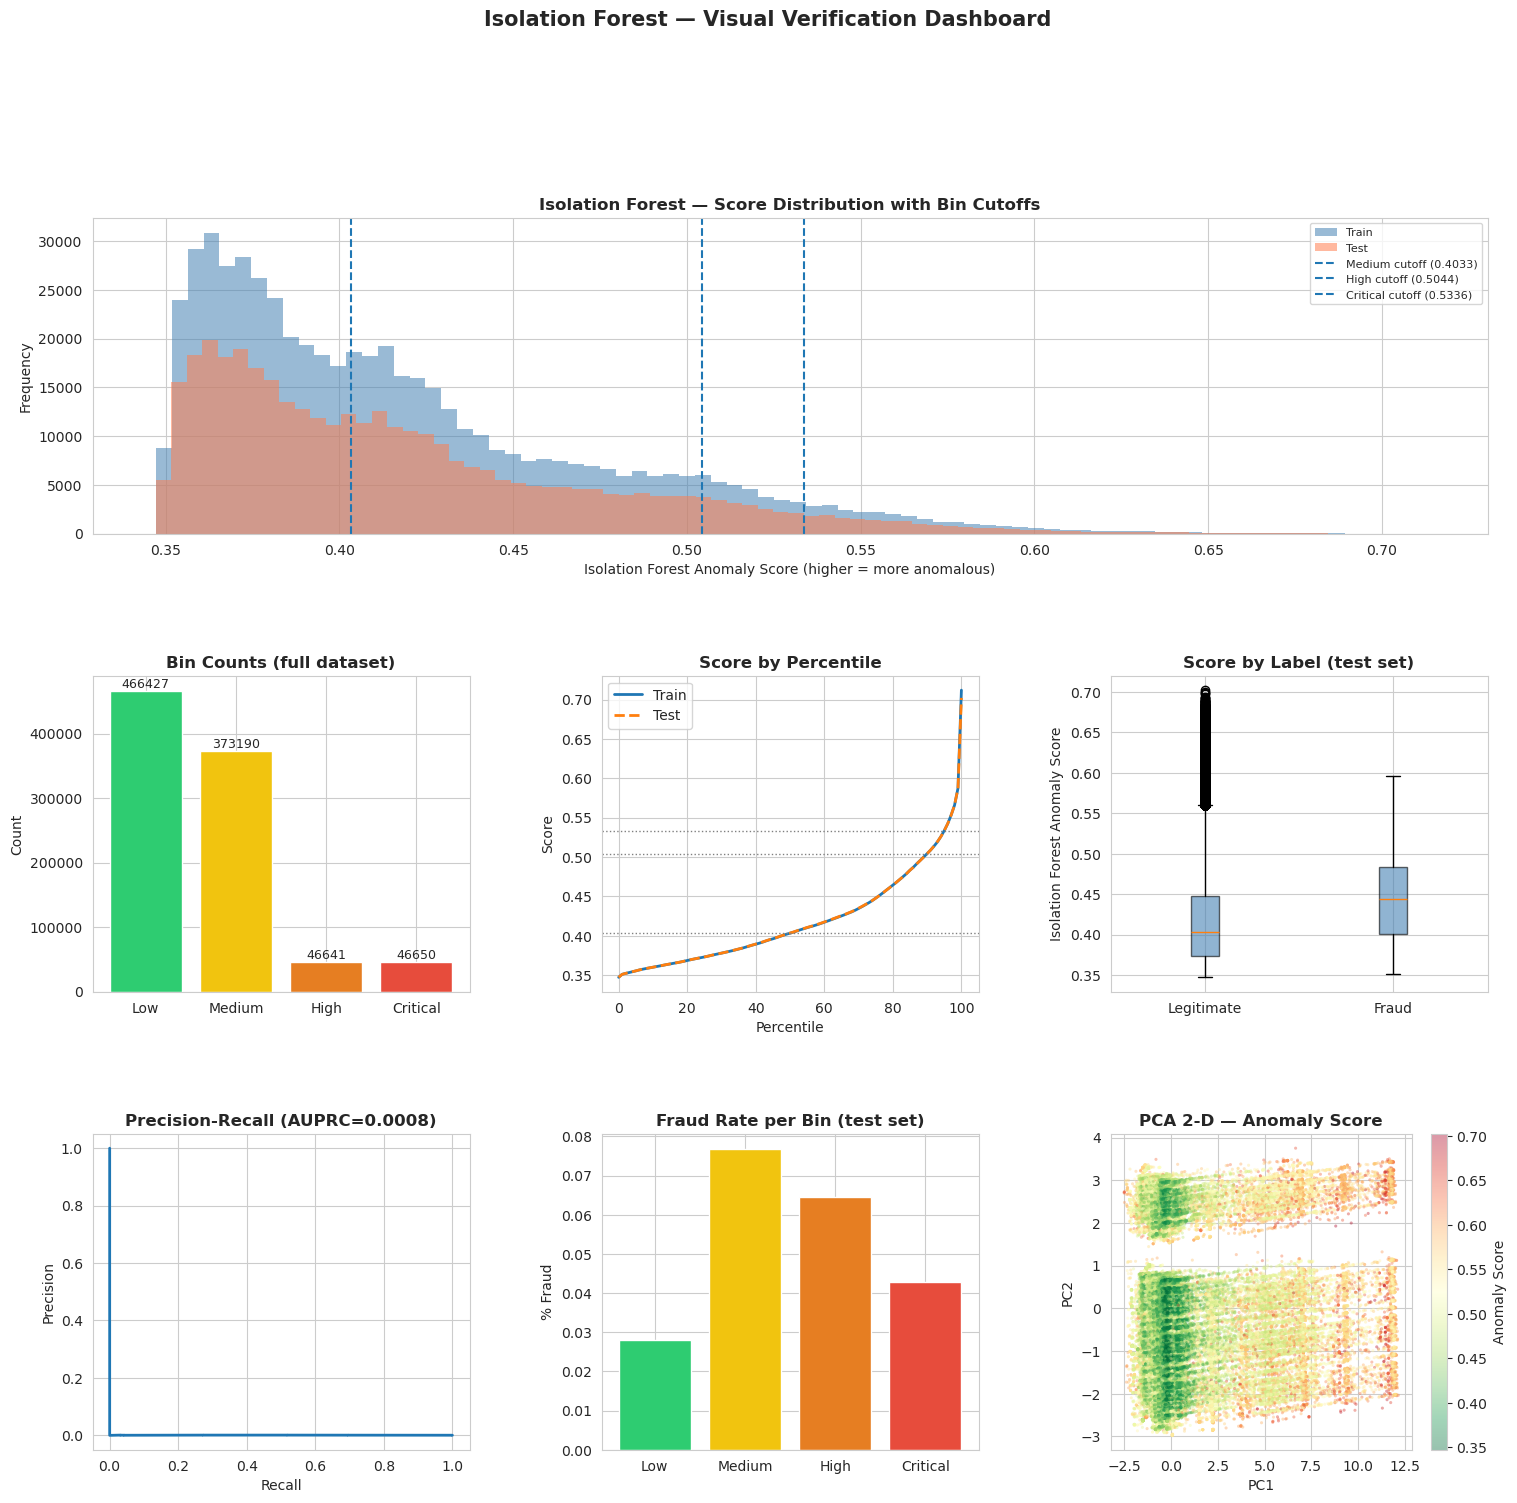


Summary: best AUPRC=0.0008
 test AUPRC=0.0008
 Critical count=46650 (5.0%)


In [12]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

#  Panel A: Score distribution 
ax_a = fig.add_subplot(gs[0, :])
ax_a.hist(train_scores, bins=80, alpha=0.55, label='Train', color='steelblue', edgecolor='none')
ax_a.hist(test_scores,  bins=80, alpha=0.55, label='Test',  color='coral',     edgecolor='none')
for c, lbl in zip(cutoffs, BIN_LABELS[1:]):
    ax_a.axvline(c, linestyle='--', linewidth=1.5, label=f'{lbl} cutoff ({c:.4f})')
ax_a.set_xlabel('Isolation Forest Anomaly Score (higher = more anomalous)')
ax_a.set_ylabel('Frequency')
ax_a.set_title('Isolation Forest — Score Distribution with Bin Cutoffs', fontweight='bold')
ax_a.legend(fontsize=8)

#  Panel B: Bin bar chart 
ax_b = fig.add_subplot(gs[1, 0])
ax_b.bar(BIN_LABELS, bin_counts.values, color=colors, edgecolor='white')
ax_b.set_title('Bin Counts (full dataset)', fontweight='bold')
ax_b.set_ylabel('Count')
for i, v in enumerate(bin_counts.values):
    ax_b.text(i, v + max(bin_counts)*0.01, str(v), ha='center', fontsize=9)

#  Panel C: Percentile curve 
ax_c = fig.add_subplot(gs[1, 1])
pcts = np.arange(0, 101, 1)
ax_c.plot(pcts, np.percentile(train_scores, pcts), label='Train', linewidth=2)
ax_c.plot(pcts, np.percentile(test_scores,  pcts), label='Test',  linewidth=2, linestyle='--')
for c in cutoffs:
    ax_c.axhline(c, color='grey', linestyle=':', linewidth=1)
ax_c.set_xlabel('Percentile')
ax_c.set_ylabel('Score')
ax_c.set_title('Score by Percentile', fontweight='bold')
ax_c.legend()

#  Panel D: Boxplot by label 
ax_d = fig.add_subplot(gs[1, 2])
ax_d.boxplot(
    [test_scores[y_test == 0], test_scores[y_test == 1]],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
ax_d.set_title('Score by Label (test set)', fontweight='bold')
ax_d.set_ylabel('Isolation Forest Anomaly Score')

#  Panel E: Precision-Recall 
ax_e = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(y_test, test_scores)
ax_e.plot(rec, prec, linewidth=2)
ax_e.set_xlabel('Recall')
ax_e.set_ylabel('Precision')
ax_e.set_title(f'Precision-Recall (AUPRC={auprc_val:.4f})', fontweight='bold')
ax_e.fill_between(rec, prec, alpha=0.15)

#  Panel F: Fraud rate per bin 
ax_f = fig.add_subplot(gs[2, 1])
test_bin_series = pd.Series(test_bins)
fraud_rate = pd.Series({
    lbl: y_test[test_bin_series == lbl].mean()
    for lbl in BIN_LABELS
})
ax_f.bar(fraud_rate.index, fraud_rate.values * 100, color=colors, edgecolor='white')
ax_f.set_title('Fraud Rate per Bin (test set)', fontweight='bold')
ax_f.set_ylabel('% Fraud')

#  Panel G: PCA 2-D scatter 
ax_g = fig.add_subplot(gs[2, 2])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Xt  = pca.fit_transform(X_test_scaled)
sc  = ax_g.scatter(Xt[:, 0], Xt[:, 1], c=test_scores, cmap='RdYlGn_r',
                   alpha=0.4, s=5, linewidths=0)
plt.colorbar(sc, ax=ax_g, label='Anomaly Score')
ax_g.set_title('PCA 2-D — Anomaly Score', fontweight='bold')
ax_g.set_xlabel('PC1')
ax_g.set_ylabel('PC2')

fig.suptitle('Isolation Forest — Visual Verification Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.show()
print(f'\nSummary: best AUPRC={best_auprc:.4f}\n test AUPRC={auprc_val:.4f}\n '
      f'Critical count={int(bin_counts["Critical"])} ({int(bin_counts["Critical"])/len(all_bins)*100:.1f}%)')

## Feature Importance Analysis


In [13]:
# baseline     = test_scores.mean()
# importances  = []

# print(f'Computing permutation importance for {len(feature_cols)} features...')
# for i, feat in enumerate(feature_cols):
#     X_perm = X_test_scaled.copy()
#     np.random.shuffle(X_perm[:, i])
#     perm_scores = -iso_forest.score_samples(X_perm)
#     importances.append(baseline - perm_scores.mean())

# importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
# importance_df = importance_df.sort_values('importance', ascending=False).head(20)

# fig, ax = plt.subplots(figsize=(12, 7))
# sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis_r', ax=ax)
# ax.set_title('Top 20 Feature Importances (permutation — Isolation Forest)', fontweight='bold')
# ax.set_xlabel('Mean anomaly-score change when feature shuffled')
# plt.tight_layout()
# plt.show()

# importance_df

## Confusion Matrix (Top 5% Anomalous as Predicted Fraud)


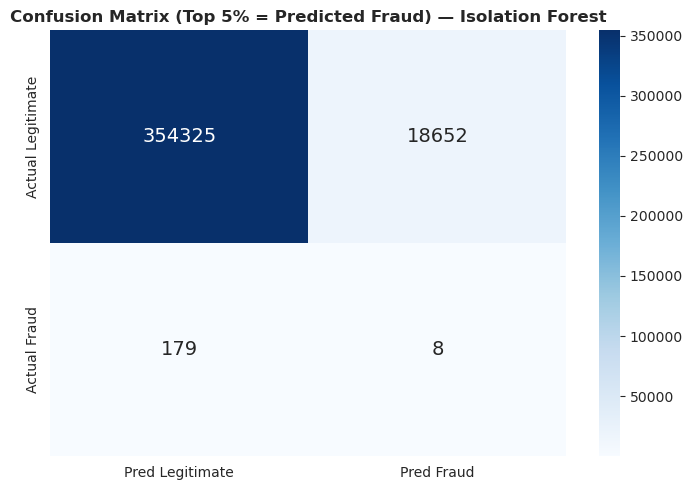

              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97    372977
       Fraud       0.00      0.04      0.00       187

    accuracy                           0.95    373164
   macro avg       0.50      0.50      0.49    373164
weighted avg       1.00      0.95      0.97    373164

Fraud capture rate in top 5%: 8/187 = 4.3%


In [14]:
top5_cutoff  = np.percentile(test_scores, 95)
y_pred_top5  = (test_scores >= top5_cutoff).astype(int)
cm           = confusion_matrix(y_test, y_pred_top5)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Legitimate', 'Pred Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix (Top 5% = Predicted Fraud) — Isolation Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_top5, target_names=['Legitimate', 'Fraud']))
print(f'Fraud capture rate in top 5%: {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%')

## Save Model and Artifacts for Ensemble Integration


In [15]:
joblib.dump(iso_forest, OUT_MODEL)
joblib.dump(scaler, OUT_SCALER)

reference_data = {
    'model_type':         'isolation_forest',
    'best_params':        best_params,
    'best_auprc':         float(best_auprc),
    'auprc':              float(auprc_val),
    'roc_auc':            float(roc_auc),
    'feature_cols':       feature_cols,
    'bin_percentiles':    BIN_PERCENTILES,
    'bin_labels':         BIN_LABELS,
    'bin_cutoffs':        cutoffs.tolist(),
    'all_score_mean':     float(all_scores.mean()),
    'all_score_std':      float(all_scores.std()),
    # 'feature_importance': importance_df.set_index('feature')['importance'].to_dict(),
}
joblib.dump(reference_data, OUT_REFS)

out_df = df[ID_COLS + [TARGET_COL]].copy()
out_df['if_anomaly_score'] = all_scores
out_df['if_anomaly_bin']   = all_bins
out_df = out_df.sort_values('if_anomaly_score', ascending=False)
out_df.to_csv(OUT_CSV, index=False)

print(f'Model  to {OUT_MODEL}')
print(f'Scaler to {OUT_SCALER}')
print(f'Refs   to {OUT_REFS}')
print(f'CSV    to {OUT_CSV}')
print(f'\nBin cutoffs persisted: {dict(zip(BIN_PERCENTILES, cutoffs.round(4)))}')
print(f'\nTop 10 most anomalous records:')
out_df.head(10)

Model  to isolation_forest_model.pkl
Scaler to isolation_forest_scaler.pkl
Refs   to isolation_forest_reference_scores.pkl
CSV    to isolation_forest_predictions.csv

Bin cutoffs persisted: {50: 0.4033, 90: 0.5044, 95: 0.5336}

Top 10 most anomalous records:


,covered_recipient_npi,record_id,program_year,target,if_anomaly_score,if_anomaly_bin
583094,1427329192,771582756,2021.0,0,0.712100,Critical
411082,1538545298,1056274809,2023.0,0,0.707572,Critical
467851,1912955238,926153075,2022.0,0,0.702272,Critical
643363,1922425560,849392119,2021.0,0,0.701486,Critical
884988,1043662018,959346791,2022.0,0,0.700403,Critical
425971,1871807172,884139709,2022.0,0,0.700002,Critical
819647,1821182361,855227199,2021.0,0,0.699414,Critical
818199,1962648410,835488313,2021.0,0,0.698580,Critical
678007,1770581357,854945305,2021.0,0,0.697628,Critical
418854,1972919702,959337985,2022.0,0,0.697479,Critical


In [16]:
#########################################################
# Aggregate IF Scores to Provider-Year
#########################################################
PROVIDER_COL = ID_COLS[0]          # 'covered_recipient_npi'
YEAR_COL     = ID_COLS[2]          # 'program_year'
CRITICAL_BIN = BIN_LABELS[-1]      # 'Critical'
HIGH_BIN     = BIN_LABELS[-2]      # 'High'
P90_CUTOFF   = cutoffs[1]          # 90th percentile
P95_CUTOFF   = cutoffs[2]          # 95th percentile

# Re-attach identifiers and scores to a single working frame
rollup_df = df[ID_COLS + [TARGET_COL]].copy()
rollup_df['if_score'] = all_scores
rollup_df['if_bin']   = all_bins

# Aggregate to provider-year
provider_year = rollup_df.groupby([PROVIDER_COL, YEAR_COL]).agg(
    if_tx_count         = ('if_score', 'count'),
    if_score_mean       = ('if_score', 'mean'),
    if_score_max        = ('if_score', 'max'),
    if_score_std        = ('if_score', 'std'),
    if_n_above_p90      = ('if_score', lambda s: (s >= P90_CUTOFF).sum()),
    if_n_above_p95      = ('if_score', lambda s: (s >= P95_CUTOFF).sum()),
    if_pct_flagged      = ('if_score', lambda s: (s >= P95_CUTOFF).mean()),
    if_n_critical       = ('if_bin',   lambda s: (s == CRITICAL_BIN).sum()),
    if_pct_critical     = ('if_bin',   lambda s: (s == CRITICAL_BIN).mean()),
    if_has_any_critical = ('if_bin',   lambda s: int((s == CRITICAL_BIN).any())),
    target              = (TARGET_COL, 'max'),
).reset_index()

OUT_ROLLUP = 'if_provider_year_rollup.csv'
output_path = "/dsa/groups/casestudycf25/team02/silver/" + OUT_ROLLUP
provider_year.to_csv(output_path, index=False)

print(f'Provider-year rollup shape: {provider_year.shape}')
print(f'Providers with any Critical transaction: {provider_year["if_has_any_critical"].sum()}')
print(f'Saved → {OUT_ROLLUP}')
provider_year.head()

Provider-year rollup shape: (158751, 13)
Providers with any Critical transaction: 17045
Saved → if_provider_year_rollup.csv


,covered_recipient_npi,program_year,if_tx_count,if_score_mean,if_score_max,if_score_std,if_n_above_p90,if_n_above_p95,if_pct_flagged,if_n_critical,if_pct_critical,if_has_any_critical,target
0,1003000597,2021.0,4,0.436717,0.448381,0.009859,0,0,0.000000,0,0.000000,0,0
1,1003000597,2022.0,17,0.434107,0.553392,0.051903,2,2,0.117647,2,0.117647,1,0
2,1003000597,2023.0,30,0.405795,0.503738,0.039483,0,0,0.000000,0,0.000000,0,0
3,1003000902,2021.0,1,0.496250,0.496250,NaN,0,0,0.000000,0,0.000000,0,0
4,1003000902,2022.0,1,0.466451,0.466451,NaN,0,0,0.000000,0,0.000000,0,0


In [17]:
from sklearn.metrics import average_precision_score
from scipy.stats import mannwhitneyu
import numpy as np

# Keep only labeled rows
labeled = out_df.dropna(subset=[TARGET_COL]).copy()

# Pull the held-out test-set scores and labels for evaluation
test_eval = pd.DataFrame({
    "target": y_test,
    "if_anomaly_score": test_scores
}).dropna(subset=["target"])

# Compute the baseline prevalence on the held-out test set
baseline = test_eval["target"].mean()

# Compute AUPRC using the correct score direction; higher score = more anomalous
auprc = average_precision_score(
    test_eval["target"],
    test_eval["if_anomaly_score"]
)

# Compute adjusted AUPRC relative to the baseline prevalence
adjusted_auprc = (auprc - baseline) / (1 - baseline)

# Split test scores by class for an independent-samples rank test
fraud_scores = test_eval.loc[
    test_eval["target"] == 1,
    "if_anomaly_score"
].to_numpy()

normal_scores = test_eval.loc[
    test_eval["target"] == 0,
    "if_anomaly_score"
].to_numpy()

# Run a one-sided Mann-Whitney U test; fraud should have higher anomaly scores
u_stat, p = mannwhitneyu(
    fraud_scores,
    normal_scores,
    alternative="greater",
    method="asymptotic"
)

# Guard against underflow when formatting extremely small p-values
p_display = f"{p:.3e}" if p > 0 else "< 1e-308"

# Print a clean summary
print(
    "DECISION GATE 2 - Isolation Forest:\n"
    f"Model AUPRC: {auprc:.4f}\n"
    f"Dataset Baseline AUPRC: {baseline:.4f}\n"
    f"Adjusted AUPRC: {adjusted_auprc:.4f}\n"
    f"Mann-Whitney U statistic: {u_stat:.1f}\n"
    f"Mann-Whitney p: {p_display}"
)

DECISION GATE 2 - Isolation Forest:
Model AUPRC: 0.0008
Dataset Baseline AUPRC: 0.0005
Adjusted AUPRC: 0.0003
Mann-Whitney U statistic: 45850325.0
Mann-Whitney p: 4.544e-14
